Cifar-10

In [ ]:
# Import thư viện và kiểm tra GPU
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


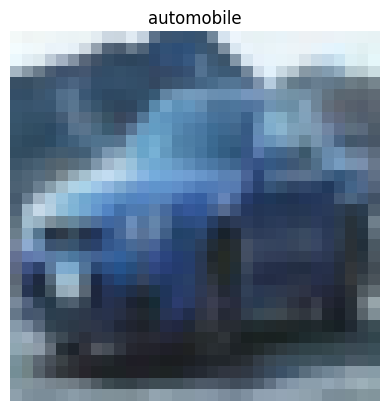

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)
Epoch 5/5  Loss = 0.4026
Accuracy = 72.91%


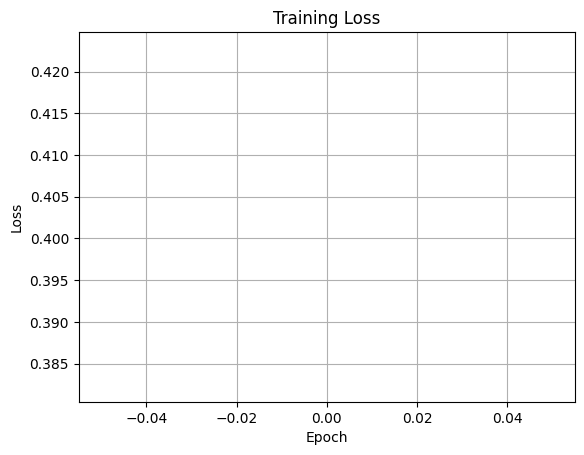

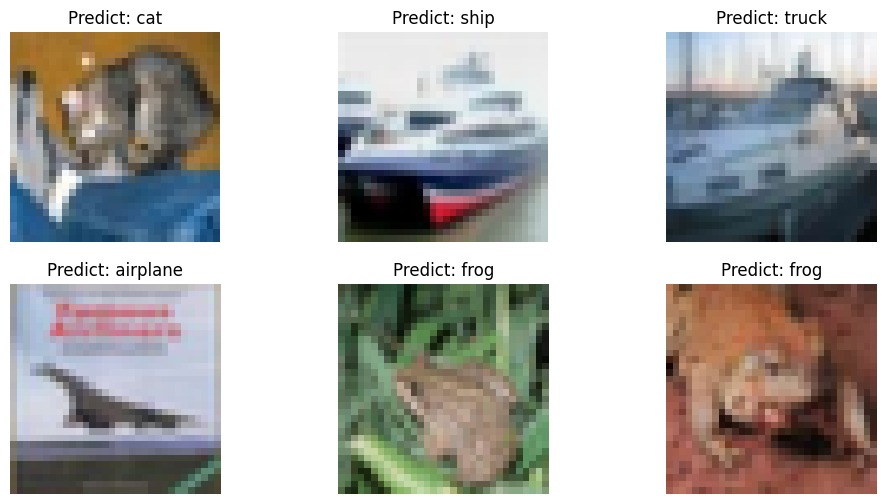

In [ ]:
# Tiền xử lý dũ liệu
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])
# Tải Cifar-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
# DataLoader
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)
# Tên các lớp
classes = (
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
)
# Hiển thị ảnh
images, labels = next(iter(train_loader))

img = images[0] / 2 + 0.5

plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.title(classes[labels[0]])
plt.axis("off")
plt.show()
# Xây dựng CNN
class CNN(nn.Module):

  def __init__(self):

    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
    )

    self.pool = nn.MaxPool2d(2, 2)

    self.conv2 = nn.Conv2d(
        32,
        64,
        3,
        padding = 1
    )

    self.fc1 = nn.Linear(
        64*8*8,
        512
    )
    self.fc2 = nn.Linear(
        512,
        10
    )
    self.relu = nn.ReLU()
  def forward(self, x):
    x = self.pool(self.relu(self.conv1(x)))
    x = self.pool(self.relu(self.conv2(x)))
    x = x.view(x.size(0), -1)
    x = self.relu(self.fc1(x))
    x = self.fc2(x)
    return x
model = CNN().to(device)
print(model)
# Loss và Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
# Train model
eepochs = 5
train_losses = []
for epoch in range(epochs):
  running_loss = 0
  model.train()
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
avg_loss = running_loss/len(train_loader)
train_losses.append(avg_loss)
print(f"Epoch {epoch+1}/{epochs}  Loss = {avg_loss:.4f}")
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device) # Fixed 'deice' to 'device'
    outputs = model(images)
    _,predicted = torch.max(outputs,1)
    total += labels.size(0)
    correct += (predicted==labels).sum().item()
print("Accuracy = %.2f%%"%(100*correct/total))
# Vẽ Loss
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()
images,labels = next(iter(test_loader))
model.eval()
outputs = model(images.to(device))
_,predicted = torch.max(outputs, 1)
plt.figure(figsize=(12, 6))
for i in range(6):
  plt.subplot(2, 3, i+1)
  img = images[i]/2+0.5
  plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
  plt.title("Predict: "+classes[predicted[i]])
  plt.axis("off")
plt.show()

CAT AND DOG

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import os # Import the os module

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

# --- Code to create necessary directories for ImageFolder ---
# Define the base directory for the dataset
base_data_dir = "dataset/train"

# Define the class names based on the intended binary classification (e.g., Cat and Dog)
class_names = ["cat", "dog"] # Assuming binary classification for cat and dog

# Create the base directory if it doesn't exist
os.makedirs(base_data_dir, exist_ok=True)

# Create subdirectories for each class if they don't exist
for class_name in class_names:
    os.makedirs(os.path.join(base_data_dir, class_name), exist_ok=True)

print(f"Created directories: {os.path.join(base_data_dir, 'cat')} and {os.path.join(base_data_dir, 'dog')}")
print("Please populate these directories with your images for 'cat' and 'dog' classes respectively.")
# --- End of directory creation code ---

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])
train_dataset = datasets.ImageFolder(
    base_data_dir, # Use the defined base_data_dir
    transform=transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
print(train_dataset.classes)
class CNN(nn.Module):

  def __init__(self):

    super().__init__()

    self.conv1 = nn.Conv2d(
        3,
        32,
        3,
        padding=1
    )

    self.conv2 = nn.Conv2d(
        32,
        64,
        3,
        padding=1
    )

    self.conv3 = nn.Conv2d(
        64,
        128,
        3,
        padding=1
    )

    self.pool = nn.MaxPool2d(2,2)

    self.relu = nn.ReLU()

    self.fc1 = nn.Linear(
        128*16*16,
        256
    )

    self.fc2 = nn.Linear(
        256,
        2
    )

  def forward(self, x):

    x = self.pool(self.relu(self.conv1(x)))

    x = self.pool(self.relu(self.conv2(x)))

    x = self.pool(self.relu(self.conv3(x)))

    x = x.view(x.size(0), -1)

    x = self.relu(self.fc1(x))

    x = self.fc2(x)

    return x
model =CNN().to(device)

print(model)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    Lr=0.001
)
epochs = 5
for epoch in range(epochs):
  running_loss = 0
  model.train()
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(
      "Epoch",
      epoch+1,
      "Loss",
      running_loss/len(train_loader)
  )

images,labels = next(iter(train_loader))
model.eval()
outputs = model(images.to(device))
_,predicted = torch.max(outputs,1)
plt.figure(figsize=(12,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = images[i]/2+0.5

    plt.imshow(np.transpose(img.numpy(),(1,2,0)))

    plt.title(
        train_dataset.classes[predicted[i]]
    )

    plt.axis("off")

plt.show()
correct = 0

total = 0

model.eval()

with torch.no_grad():

    for images,labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _,predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

print("Accuracy:",100*correct/total)

cuda
Created directories: dataset/train/cat and dataset/train/dog
Please populate these directories with your images for 'cat' and 'dog' classes respectively.


FileNotFoundError: Found no valid file for the classes cat, dog. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp